# Activity inference in video – Reproduction des algorithmes

Ce notebook implémente, sous forme modulaire et commentée, l'ensemble des algorithmes décrits dans le rapport *Activity inference in video* (Aurélien Louis, 2004).

## 1. Préliminaires et dépendances

In [2]:
import numpy as np
import scipy as sp
import scipy.spatial
import scipy.optimize
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.sparse.linalg import eigsh

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from tqdm import tqdm
from sklearn.datasets import fetch_openml

## 2. Extraction des contours et points de contrôle (Section 2.2.1)

In [3]:
def extract_edges(image, low=100, high=200):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Canny(gray, low, high)


def sample_contour_points(edges, n_points=100):
    ys, xs = np.where(edges > 0)
    if len(xs) == 0:
        return np.empty((0, 2))
    idx = np.linspace(0, len(xs) - 1, n_points).astype(int)
    return np.stack([xs[idx], ys[idx]], axis=1)

## 3. Shape Contexts (Sections 2.2.2–2.2.3)

In [4]:

def shape_context(points, n_r=5, n_theta=12):
    dists = sp.spatial.distance.cdist(points, points)
    mean_dist = dists.mean()
    dists /= mean_dist
    angles = np.arctan2(points[:, None, 1] - points[None, :, 1],
                        points[:, None, 0] - points[None, :, 0])

    r_bins = np.logspace(-1, 1, n_r)
    t_bins = np.linspace(-np.pi, np.pi, n_theta + 1)
    contexts = []

    for i in range(len(points)):
        hist = np.zeros((n_r, n_theta))
        for j in range(len(points)):
            if i == j:
                continue
            r = dists[i, j]
            t = angles[i, j]
            rb = np.searchsorted(r_bins, r) - 1
            tb = np.searchsorted(t_bins, t) - 1
            if 0 <= rb < n_r and 0 <= tb < n_theta:
                hist[rb, tb] += 1
        hist /= hist.sum() + 1e-8
        contexts.append(hist.flatten())
    return np.array(contexts)


def chi2_cost(h1, h2):
    return 0.5 * np.sum((h1 - h2)**2 / (h1 + h2 + 1e-8))


## 4. Appariement optimal – Algorithme hongrois (2.2.3)

In [5]:

def matching_cost(ctx1, ctx2):
    C = np.zeros((len(ctx1), len(ctx2)))
    for i in range(len(ctx1)):
        for j in range(len(ctx2)):
            C[i, j] = chi2_cost(ctx1[i], ctx2[j])
    return C


def hungarian_matching(C):
    r, c = sp.optimize.linear_sum_assignment(C)
    return list(zip(r, c))


## 5. Distance entre formes (Section 2.2.5)

In [10]:

def shape_distance(cost_matrix, matching):
    return np.mean([cost_matrix[i, j] for i, j in matching])


## 6. Embedding spectral (Sections 1.3.1–1.3.4)

In [163]:

def spectral_embedding(W, n_dims=5):
    D = np.diag(W.sum(axis=1))
    L = D - W
    vals, vecs = eigsh(L, k=n_dims + 1, M=D, which='SM')
    return vecs[:, 1:n_dims+1]


## 7. Clustering final des activités

In [12]:

def cluster_embedding(X, K):
    return KMeans(n_clusters=K).fit_predict(X)


## Tests du notebook
Tout d'abord, charger MNIST

In [37]:
def load_mnist(n_train=300, n_test=100, random_state=0):
    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    X = mnist.data.reshape(-1, 28, 28).astype(np.uint8)
    y = mnist.target.astype(int)

    return X, y


X, y = load_mnist()


np.int64(0)

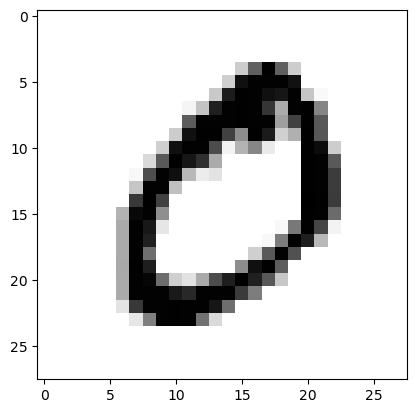

In [40]:
plt.imshow(X[1].reshape(28, 28), cmap='gray_r')
y[1]

Détecter les contours et déterminer les points de contrôle

In [133]:
def image_to_points(img, n_points=20):
    edges = cv2.Canny(img, 80, 160)
    ys, xs = np.where(edges > 0)

    if len(xs) < n_points:
        return None  # rejet image trop pauvre

    idx = np.linspace(0, len(xs) - 1, n_points).astype(int)
    points = np.stack([xs[idx], ys[idx]], axis=1)
    return points


In [134]:
def build_shapes(X):
    shapes = []
    for img in tqdm(X):
        pts = image_to_points(img)
        shapes.append(pts)
    return shapes

shapes = build_shapes(X)

100%|██████████| 70000/70000 [00:04<00:00, 17011.62it/s]


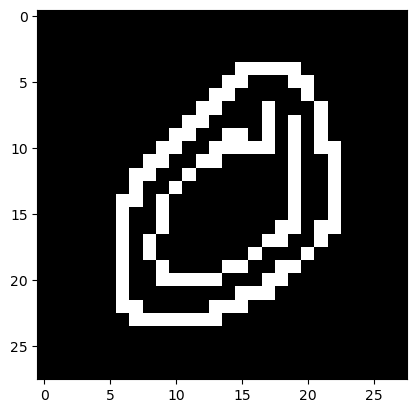

In [135]:
plt.imshow(cv2.Canny(X[1],80,160), cmap='gray')
plt.show()

In [136]:
img = image_to_points(X[1],50)
img

array([[15,  4],
       [17,  4],
       [19,  4],
       [15,  5],
       [20,  5],
       [14,  6],
       [12,  7],
       [21,  7],
       [12,  8],
       [19,  8],
       [10,  9],
       [14,  9],
       [17,  9],
       [ 9, 10],
       [13, 10],
       [15, 10],
       [17, 10],
       [21, 10],
       [ 8, 11],
       [13, 11],
       [22, 11],
       [ 8, 12],
       [19, 12],
       [ 7, 13],
       [19, 13],
       [ 7, 14],
       [19, 14],
       [ 6, 15],
       [19, 15],
       [ 6, 16],
       [18, 16],
       [22, 16],
       [ 8, 17],
       [18, 17],
       [ 6, 18],
       [16, 18],
       [ 6, 19],
       [15, 19],
       [19, 19],
       [ 9, 20],
       [11, 20],
       [13, 20],
       [18, 20],
       [16, 21],
       [ 6, 22],
       [13, 22],
       [15, 22],
       [ 8, 23],
       [10, 23],
       [13, 23]])

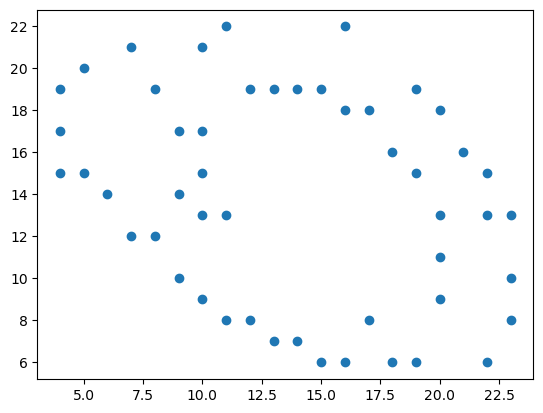

In [137]:
plt.scatter(img[:,1], img[:,0])
plt.show()

Calcul du contexte

In [138]:
def compute_shape_contexts(shapes):
    contexts = []
    for pts in tqdm(shapes):
        if pts is None:
            contexts.append(None)
        else:
            contexts.append(shape_context(pts))
    return contexts


ctx = compute_shape_contexts(shapes[:100])



100%|██████████| 100/100 [00:00<00:00, 517.36it/s]


Calcul un peu long tout de même...

In [139]:
def shape_context_distance(ctx1, ctx2):
    if ctx1 is None or ctx2 is None:
        return np.inf

    C = matching_cost(ctx1, ctx2)
    matching = hungarian_matching(C)
    return shape_distance(C, matching)

In [140]:
def compute_distance_matrix(train_ctx, test_ctx):
    D = np.zeros((len(test_ctx), len(train_ctx)))

    for i, ctx_test in enumerate(tqdm(test_ctx)):
        for j, ctx_train in enumerate(train_ctx):
            D[i, j] = shape_context_distance(ctx_test, ctx_train)

    return D


D = compute_distance_matrix(ctx, ctx)


100%|██████████| 100/100 [00:24<00:00,  4.00it/s]


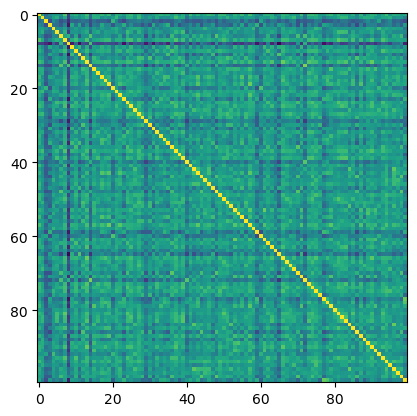

In [162]:
plt.imshow(1-D)

In [158]:
D[2,2]

np.float64(0.0)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(20, 60))

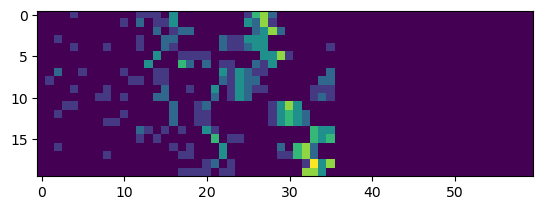

In [142]:
plt.imshow(ctx[1])
ctx[1]

In [164]:
eigen=spectral_embedding(1-D)
groups=cluster_embedding(D, 10)

C:\Users\LOUISA\AppData\Local\anaconda3\envs\Toolbox\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [165]:
groups

array([7, 2, 0, 3, 2, 2, 4, 5, 8, 6, 9, 6, 1, 5, 4, 1, 2, 7, 9, 7, 0, 5,
       9, 3, 5, 5, 1, 1, 4, 0, 4, 6, 5, 7, 9, 6, 4, 5, 2, 5, 3, 7, 9, 9,
       4, 9, 9, 6, 4, 1, 9, 2, 4, 7, 1, 7, 2, 7, 5, 3, 0, 7, 9, 7, 0, 6,
       5, 5, 2, 2, 4, 7, 4, 5, 1, 5, 4, 3, 3, 7, 2, 5, 2, 5, 4, 9, 4, 7,
       0, 7, 5, 7, 0, 5, 1, 2, 9, 9, 4, 3], dtype=int32)

In [168]:
groups-y[:100]

array([ 2,  2, -4,  2, -7,  0,  3,  2,  7,  2,  6,  1, -2, -1,  3, -6,  0,
       -1,  3, -2, -4,  5,  0,  2,  4,  3, -3, -2,  2, -7,  1, -2, -1, -2,
        9,  1, -2,  5, -5, -1,  2, -1,  2,  0,  1,  0,  1,  1, -5, -2,  6,
        2, -3,  3, -8, -1,  2, -2,  1,  2, -4,  3,  3,  7, -4,  1, -1,  4,
        2,  2,  3,  0,  3, -1, -2,  5,  2,  2,  2,  0, -7,  5,  0, -1, -3,
        1,  1, -2,  0,  3, -1,  0, -4, -1, -7,  2,  2,  1,  1,  2])

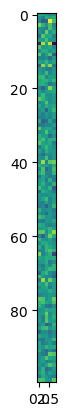

In [169]:
plt.imshow(eigen)


In [34]:
def knn_from_distance(D, y_train, k=3):
    y_pred = []
    for row in D:
        nn = np.argsort(row)[:k]
        labels = y_train[nn]
        y_pred.append(np.bincount(labels).argmax())
    return np.array(y_pred)


y_pred = knn_from_distance(D_test_train, y_train, k=3)

In [35]:

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy MNIST (Shape Context + {3}-NN): {acc:.4f}")


Accuracy MNIST (Shape Context + 3-NN): 0.2700
